In [34]:
import logging
import sys
import os
from os.path import join
from copy import deepcopy

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from IPython.display import display, clear_output
from tqdm import tqdm

# sys.path.insert(0, "/home/2649/repos/ABC-SN/code")
# import abcsn_config
# import abcsn_training
# import data_degrading as dg
# import data_plotting as dplt
# import data_preparation as dp
# import preprocessing

sys.path.insert(0, "/home/2649/repos/spec_res/code")
import review_spectrum as rs
import spectral_features as sf
import measure_signal as ms

from importlib import reload

In [2]:
df_data, df_metadata, wvl = rs.load_sn_data()
FFTd_S_data, FFTd_S_metadata, FFTd_N_data, FFTd_N_metadata = rs.load_FFTdenoised_data()

In [3]:
reload(ms)
logging.getLogger().setLevel(logging.WARNING)
specsnr_objs = []
for i in tqdm(range(df_data.shape[0])):
    if df_metadata["SN Subtype"][i] != "Ia-norm":
        continue
    if df_metadata["Spectral Phase"][i] >= 14:
        continue

    specsnr = ms.SpectrumSNR(
        df_metadata["SN Name"][i],
        df_metadata["SN Subtype"][i],
        df_metadata["Spectral Phase"][i],
        wvl,
        deepcopy(df_data.loc[i].values)
    )
    specsnr.summarize()
    specsnr.set_spectral_feature()
    specsnr.denoise_gaussian(10)
    specsnr.find_spectral_line(feature_search_bounds=(500, 0), plot=False)
    specsnr.find_spectral_shoulders(plot=False)
    specsnr.calc_pEW(plot=False)
    specsnr.measure_feature_noise(plot=False)
    specsnr.measure_SNR(plot=False)
    specsnr_objs.append(specsnr)

100%|██████████| 3764/3764 [01:28<00:00, 42.60it/s] 


In [32]:
sort_by_SNR = np.argsort([specsnr.SNR for specsnr in specsnr_objs])
sorted_specsnr_objs = np.array(specsnr_objs)[sort_by_SNR][::-1]

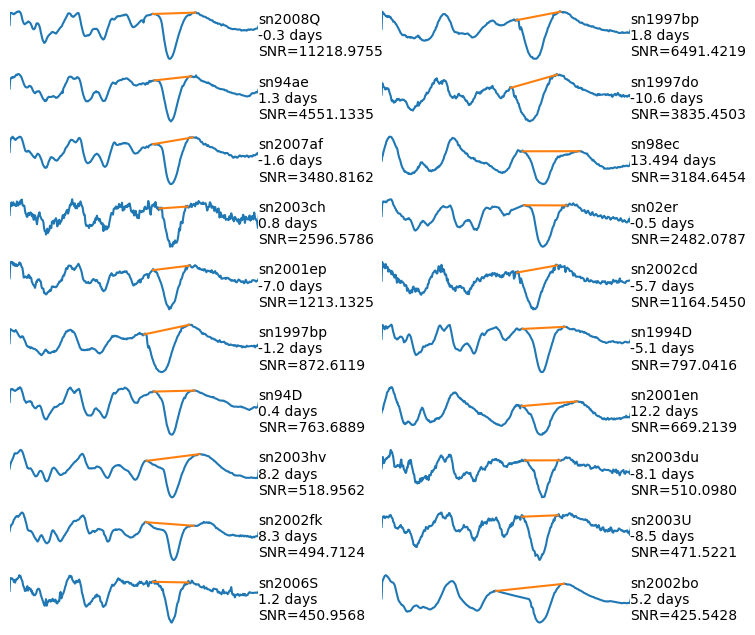

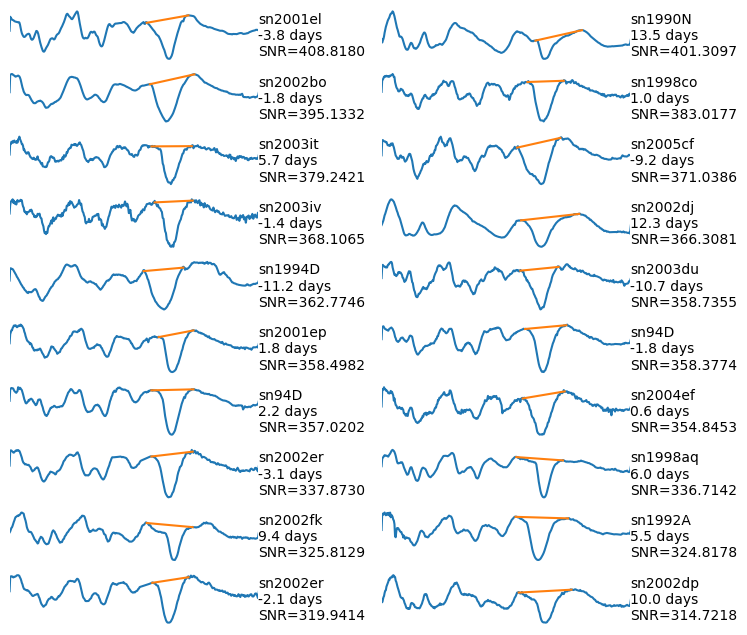

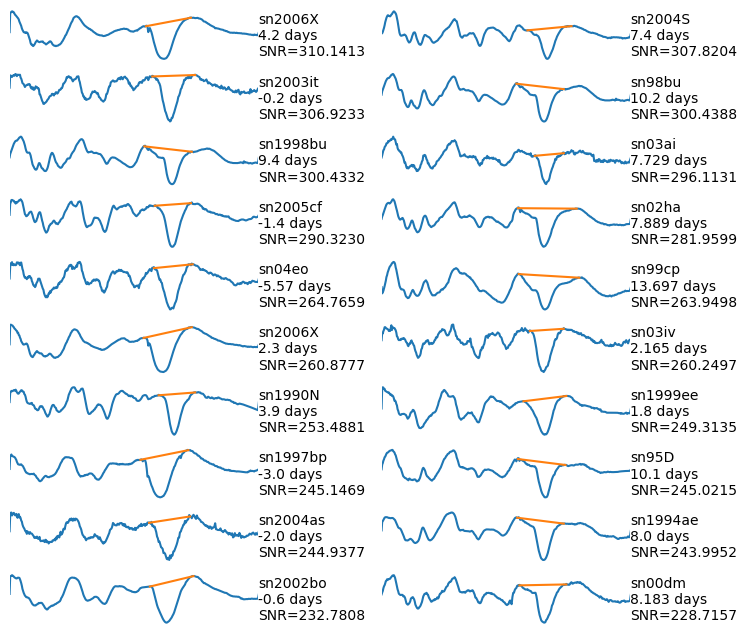

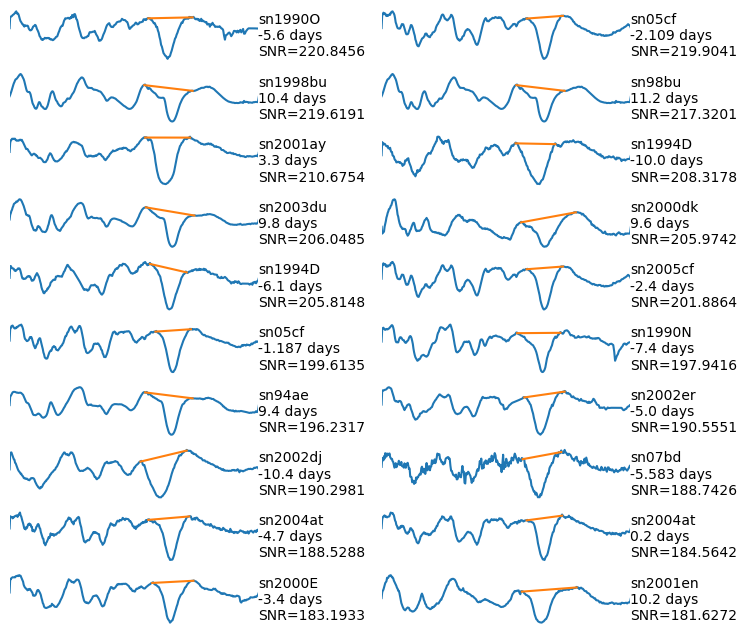

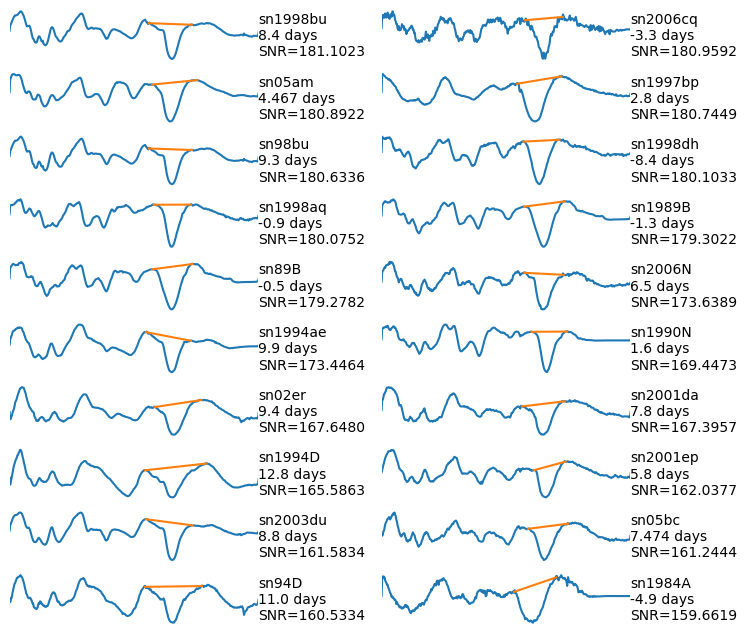

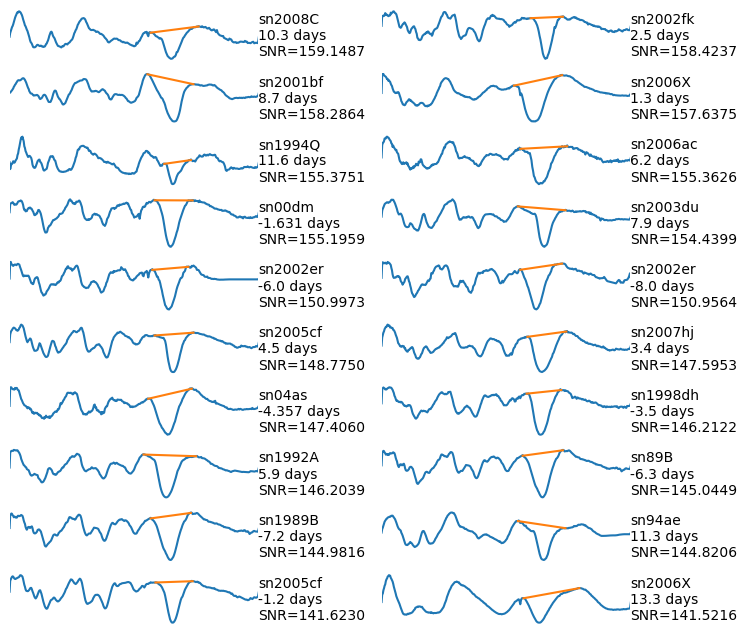

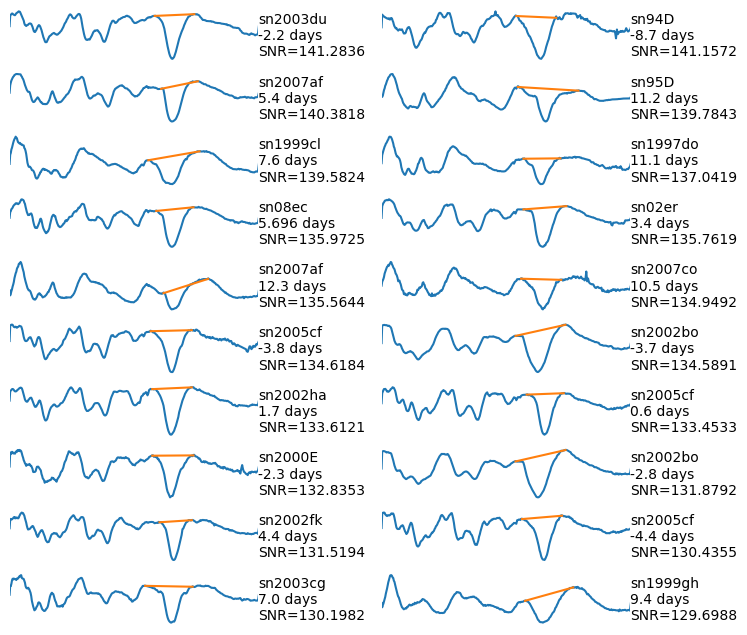

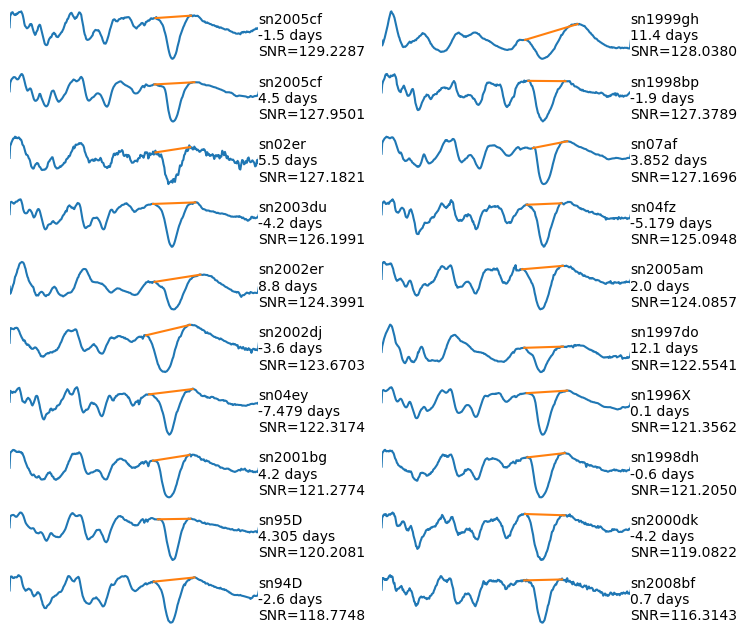

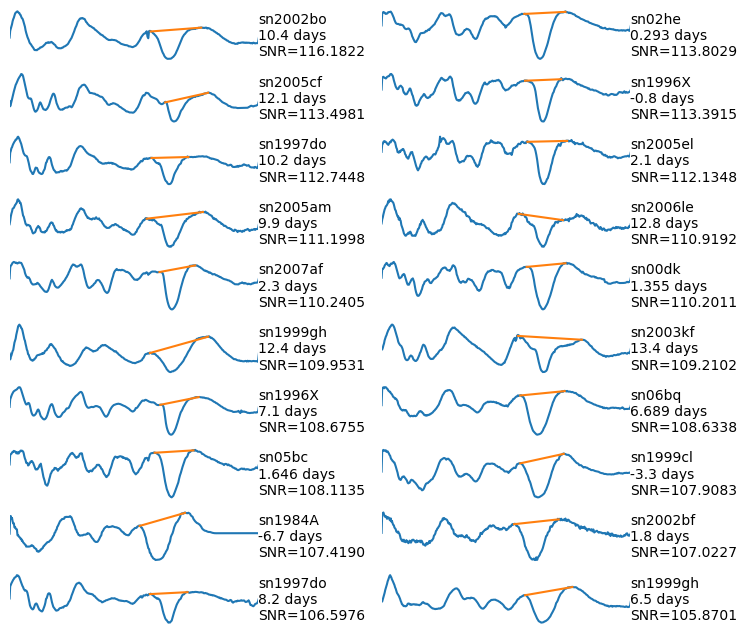

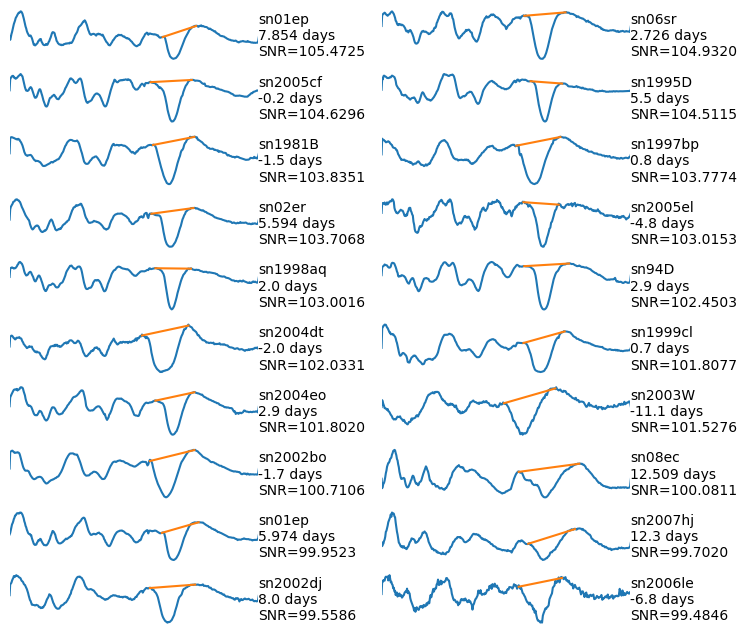

In [30]:
for i in range(10):
    i *= 20
    sort_by_SNR = np.argsort([specsnr.SNR for specsnr in specsnr_objs])
    sorted_specsnr_objs = np.array(specsnr_objs)[sort_by_SNR][::-1][i:i+20]
    
    fig, axes = plt.subplots(ncols=2, nrows=10, sharex=True, figsize=(8, 8))
    fig.subplots_adjust(wspace=.5)
    axes.flatten()[0].set_xlim((4500, 7000))
    for i, ax in enumerate(axes.flatten()):
        ax.axis("off")
        specsnr_i = sorted_specsnr_objs[i]
        ax.plot(wvl, specsnr_i.spectrum)
        vertical_midpoint = np.sum(ax.get_ylim()) / 2
        horizontal_text_location = ax.get_xlim()[1]
        ax.text(
            horizontal_text_location, vertical_midpoint,
            f"{specsnr_i.name}\n{specsnr_i.phase} days\nSNR={specsnr_i.SNR:.4f}",
            ha="left", va="center"
        )
        ax.plot(specsnr_i.pc_wvl, specsnr_i.pseudo_cont, c="tab:orange")
    
    fig.show()